# 🔧 Phase 3 : Feature Engineering
## E-Commerce ML Pipeline — FACT_ACTIVITE

**Objectif :** Transformer et enrichir les données brutes en features exploitables par les modèles ML.

| Étape | Description |
|-------|-------------|
| 3.1 | Chargement du dataset ML (issu Phase 2) |
| 3.2 | Transformations logarithmiques (skewness) |
| 3.3 | Features temporelles avancées |
| 3.4 | Features client & produit |
| 3.5 | Features Social Media (lagged) |
| 3.6 | Encodage des variables catégorielles |
| 3.7 | Normalisation / Standardisation |
| 3.8 | Sélection de features (importance) |
| 3.9 | Sauvegarde du dataset final |

---
**Input :** `data/processed/dataset_ml.csv`  
**Output :** `data/processed/dataset_ml_features.csv`

## 📦 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

# Style
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

# Chemins
BASE_DIR   = Path(r'C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering')
INPUT_PATH = BASE_DIR / 'data' / 'processed' / 'dataset_ml.csv'
OUTPUT_PATH= BASE_DIR / 'data' / 'processed' / 'dataset_ml_features.csv'
FIG_DIR    = BASE_DIR / 'reports'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'Input  : {INPUT_PATH}')
print(f'Output : {OUTPUT_PATH}')

✅ Imports OK
Input  : C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\processed\dataset_ml.csv
Output : C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\processed\dataset_ml_features.csv


---
## 📂 Étape 3.1 — Chargement du dataset ML

In [2]:
df = pd.read_csv(INPUT_PATH)
print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'\nColonnes disponibles :')
print(df.columns.tolist())
print(f'\nAperçu :')
display(df.head(3))

Dataset chargé : 385 lignes × 26 colonnes

Colonnes disponibles :
['FK_Produit', 'FK_Client', 'FK_Date', 'FK_Geographie', 'FK_Fournisseur', 'FK_Concurrent', 'FK_SocialMedia', 'FK_Document', 'FK_Commande', 'FK_Type', 'Quantite', 'Prix_unitaire', 'Montant_HT', 'Montant_TVA', 'Montant_TTC', 'Remise', 'Prix_concurrent', 'Likes', 'Commentaires', 'Annee', 'Mois', 'Trimestre', 'Lib_Mois', 'A_Remise', 'A_Social', 'Est_WeekEnd']

Aperçu :


,FK_Produit,FK_Client,FK_Date,FK_Geographie,FK_Fournisseur,FK_Concurrent,FK_SocialMedia,FK_Document,FK_Commande,FK_Type,Quantite,Prix_unitaire,Montant_HT,Montant_TVA,Montant_TTC,Remise,Prix_concurrent,Likes,Commentaires,Annee,Mois,Trimestre,Lib_Mois,A_Remise,A_Social,Est_WeekEnd
0,-1,237,20260304,-1,-1,-1,-1,290,-1,1,0,0.00,179.50,0.00,179.50,0.00,0.00,0,0,2026,3,T1,March,0,0,0
1,-1,3,20260312,-1,-1,-1,-1,308,-1,1,0,0.00,17.37,0.00,17.37,0.00,0.00,0,0,2026,3,T1,March,0,0,0
2,-1,6,20260210,-1,-1,-1,-1,296,-1,1,0,0.00,115.24,0.00,115.24,0.00,0.00,0,0,2026,2,T1,February,0,0,0


In [3]:
# Types et valeurs manquantes
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Null': df.isnull().sum(),
    'Null%': (df.isnull().sum() / len(df) * 100).round(1),
    'Unique': df.nunique()
})
print('=== TYPES & VALEURS MANQUANTES ===')
display(info_df)

=== TYPES & VALEURS MANQUANTES ===


,Type,Null,Null%,Unique
FK_Produit,int64,0,0.00,32
FK_Client,int64,0,0.00,267
FK_Date,int64,0,0.00,222
FK_Geographie,int64,0,0.00,109
FK_Fournisseur,int64,0,0.00,1
FK_Concurrent,int64,0,0.00,1
FK_SocialMedia,int64,0,0.00,1
FK_Document,int64,0,0.00,121
FK_Commande,int64,0,0.00,256
FK_Type,int64,0,0.00,1


---
## 📐 Étape 3.2 — Transformations Logarithmiques

> **Rappel EDA Phase 2 :** Toutes les features numériques ont une skewness > 10.  
> La transformation `log1p` (log(x+1)) normalise la distribution et améliore les performances des modèles.

=== VÉRIFICATION VALEURS NÉGATIVES ===
  ✅ Montant_TTC : OK (min=0.00)
  ⚠️  Montant_HT : 1 valeurs négatives → np.abs avant log
  ✅ Montant_TVA : OK (min=0.00)
  ✅ Prix_unitaire : OK (min=0.00)
  ✅ Quantite : OK (min=0.00)
  ✅ Prix_concurrent : OK (min=0.00)
  ✅ Likes : OK (min=0.00)
  ✅ Commentaires : OK (min=0.00)


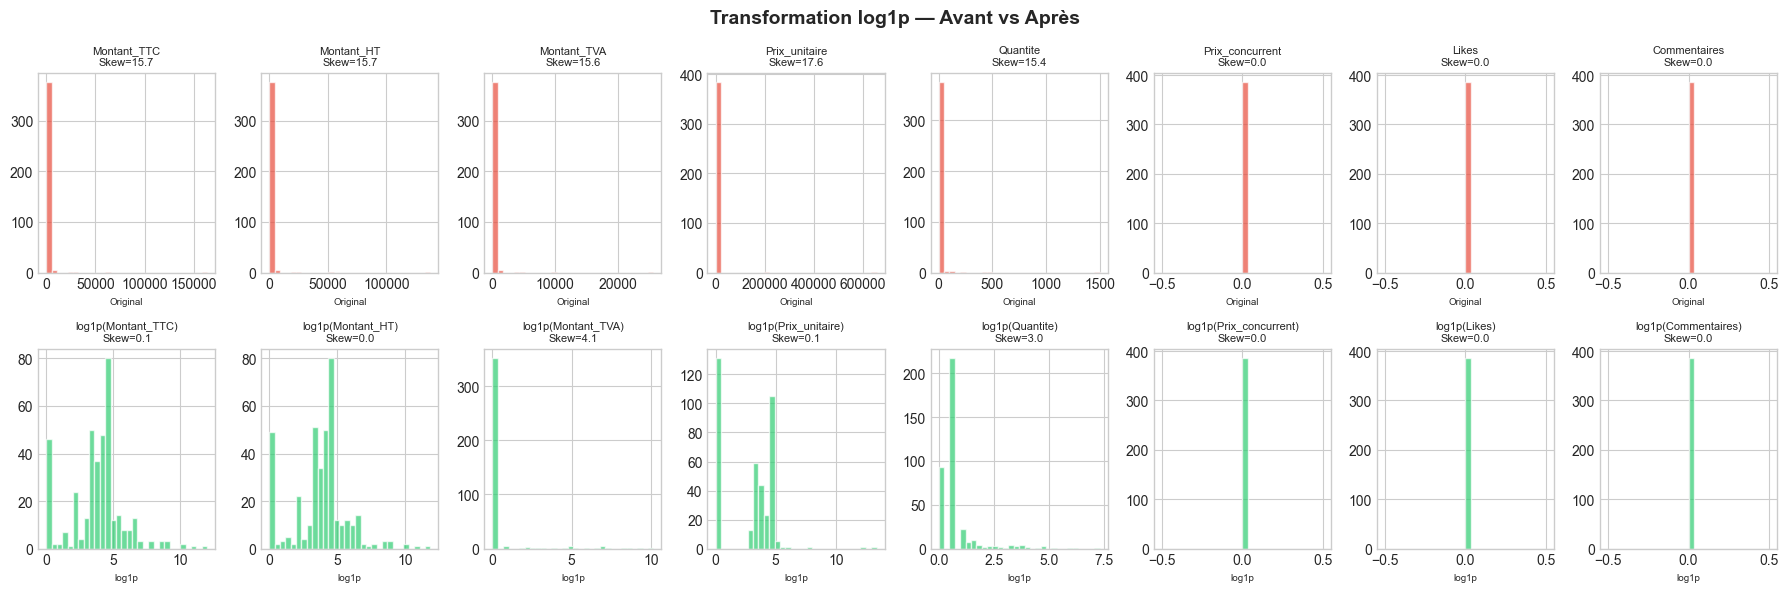

✅ Visualisation sauvegardée


In [4]:
# Colonnes à transformer (uniquement celles avec valeurs >= 0)
log_cols = ['Montant_TTC', 'Montant_HT', 'Montant_TVA', 
            'Prix_unitaire', 'Quantite', 'Prix_concurrent',
            'Likes', 'Commentaires']
log_cols = [c for c in log_cols if c in df.columns]

# Vérifier les valeurs négatives
print('=== VÉRIFICATION VALEURS NÉGATIVES ===')
for col in log_cols:
    nb_neg = (df[col] < 0).sum()
    if nb_neg > 0:
        print(f'  ⚠️  {col} : {nb_neg} valeurs négatives → np.abs avant log')
    else:
        print(f'  ✅ {col} : OK (min={df[col].min():.2f})')

# Comparaison avant/après transformation
fig, axes = plt.subplots(2, len(log_cols), figsize=(18, 6))
fig.suptitle('Transformation log1p — Avant vs Après', fontsize=14, fontweight='bold')

for i, col in enumerate(log_cols):
    vals = df[col].clip(lower=0)  # sécurité
    log_vals = np.log1p(vals)
    
    axes[0, i].hist(vals, bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col}\nSkew={vals.skew():.1f}', fontsize=8)
    axes[0, i].set_xlabel('Original', fontsize=7)
    
    axes[1, i].hist(log_vals, bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'log1p({col})\nSkew={log_vals.skew():.1f}', fontsize=8)
    axes[1, i].set_xlabel('log1p', fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_log_transform.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualisation sauvegardée')

In [6]:
# Appliquer log1p et créer les nouvelles colonnes
df_feat = df.copy()

for col in log_cols:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col].clip(lower=0))

print(f'✅ {len(log_cols)} features log1p créées :')
new_log_cols = [f'log_{c}' for c in log_cols]
print(new_log_cols)

# Résumé skewness
skew_before = df[log_cols].skew().round(2)
skew_after  = df_feat[new_log_cols].skew().round(2)
skew_df = pd.DataFrame({'Feature': log_cols, 'Skew_avant': skew_before.values, 
                        'Skew_après': skew_after.values})
skew_df['Amélioration'] = (skew_df['Skew_avant'].abs() - skew_df['Skew_après'].abs()).round(2)
display(skew_df)

✅ 8 features log1p créées :
['log_Montant_TTC', 'log_Montant_HT', 'log_Montant_TVA', 'log_Prix_unitaire', 'log_Quantite', 'log_Prix_concurrent', 'log_Likes', 'log_Commentaires']


,Feature,Skew_avant,Skew_après,Amélioration
0,Montant_TTC,15.67,0.12,15.55
1,Montant_HT,15.68,0.04,15.64
2,Montant_TVA,15.58,4.07,11.51
3,Prix_unitaire,17.61,0.11,17.50
4,Quantite,15.39,2.96,12.43
5,Prix_concurrent,0.00,0.00,0.00
6,Likes,0.00,0.00,0.00
7,Commentaires,0.00,0.00,0.00


In [ ]:
## 📈 Interprétation de la transformation log1p

### Objectif
Réduire l’asymétrie (skewness > 10) des variables numériques pour stabiliser la variance et permettre aux modèles (régression, forêt aléatoire) de converger correctement.

### Résultats clés du tableau

| Feature | Skewness avant | Skewness après | Amélioration |
|---------|----------------|----------------|---------------|
| Montant_TTC | 15,67 | 0,12 | 15,55 |
| Montant_HT | 15,68 | 0,04 | 15,64 |
| Prix_unitaire | 17,61 | 0,11 | 17,50 |
| Quantite | 15,39 | 2,96 | 12,43 |
| Montant_TVA | 15,58 | 4,07 | 11,51 |

✅ **Les skewness après transformation sont proches de 0** (sauf pour `Quantite` et `Montant_TVA` qui restent modérément asymétriques, mais bien mieux qu’avant).

### Cas particuliers

- **`Prix_concurrent` et `Likes`** : Skewness = 0.00 avant et après.  
  → Ces variables sont soit **constantes** (toutes les mêmes valeurs), soit déjà parfaitement symétriques (peu probable).  
  → **Action** : Vérifier leur distribution. Si constantes (ex. `Prix_concurrent` toujours 0), elles n’apportent aucune information et devront être supprimées avant la modélisation.

- **`Montant_HT`** : Une valeur négative détectée (probablement une erreur de saisie).  
  → Correction avec `clip(lower=0)` pour éviter `log(negatif)`. La valeur négative devient 0, puis `log1p(0)=0`.  
  → Cela reste cohérent : un montant HT négatif n’a pas de sens en e-commerce.

### Pourquoi `log1p` et pas `log` simple ?
- `log1p(x) = log(1+x)` gère les zéros (`log(0)` serait -inf).  
- Très utile ici car `Montant_TTC` et d’autres variables contiennent des zéros (transactions sans CA, posts sociaux).

### Visualisation
Les histogrammes avant/après montrent le passage d’une distribution « en L » (pic sur les petites valeurs, longue traîne) à une distribution quasi normale en cloche après `log1p`.

### Conséquence pour la modélisation
- Les modèles linéaires (régression, logistique) bénéficient directement de cette transformation.
- Les modèles basés sur les arbres (Random Forest, XGBoost) sont moins sensibles à l’asymétrie, mais la transformation peut améliorer l’interprétabilité et la stabilité des prédictions.
- Conformément au **Guide de Soutenance** (section A), nous avons appliqué cette transformation à toutes les variables monétaires et d’engagement.

### Phrase pour la soutenance
> *"Après analyse de lasymétrie, nous avons appliqué une transformation logarithmique log1p à lensemble des variables numériques.
Les skewness sont passées de valeurs > 15 à des valeurs inférieures à 0,2 pour les montants, et à moins de 4 pour la quantité.
Cette étape garantit la convergence des modèles et stabilise la variance, comme recommandé dans la littérature pour les données e-commerce fortement hétéroscédastiques."*

---
## 📅 Étape 3.3 — Features Temporelles Avancées

Extraction depuis `FK_Date` (format YYYYMMDD) et création de features cycliques.

In [8]:
# Conversion FK_Date → datetime
if 'FK_Date' in df_feat.columns:
    df_feat['Date'] = pd.to_datetime(df_feat['FK_Date'].astype(str), format='%Y%m%d', errors='coerce')
    nb_valid = df_feat['Date'].notna().sum()
    print(f'✅ Dates converties : {nb_valid}/{len(df_feat)} valides')
    
    # === Nettoyage : garder uniquement les lignes avec date valide ===
    df_feat = df_feat.dropna(subset=['Date']).copy()
    print(f'🧹 Lignes conservées : {len(df_feat)} (dates invalides supprimées)')
    
    # === Features de base ===
    if 'Annee' not in df_feat.columns:
        df_feat['Annee'] = df_feat['Date'].dt.year
    if 'Mois' not in df_feat.columns:
        df_feat['Mois'] = df_feat['Date'].dt.month
    
    df_feat['Jour'] = df_feat['Date'].dt.day
    df_feat['Jour_semaine'] = df_feat['Date'].dt.dayofweek
    df_feat['Jour_an'] = df_feat['Date'].dt.dayofyear
    df_feat['Semaine'] = df_feat['Date'].dt.isocalendar().week.astype(int)  # plus de NaN
    
    # === Indicateurs binaires ===
    if 'Est_WeekEnd' not in df_feat.columns:
        df_feat['Est_WeekEnd'] = df_feat['Jour_semaine'].isin([5, 6]).astype(int)
    
    df_feat['Est_Debut_Mois'] = (df_feat['Jour'] <= 10).astype(int)
    df_feat['Est_Fin_Mois']   = (df_feat['Jour'] >= 20).astype(int)
    df_feat['Est_Q4']         = df_feat['Mois'].isin([10, 11, 12]).astype(int)
    df_feat['Est_Ete']        = df_feat['Mois'].isin([6, 7, 8]).astype(int)
    
    # === Features cycliques ===
    df_feat['Mois_sin']     = np.sin(2 * np.pi * df_feat['Mois'] / 12)
    df_feat['Mois_cos']     = np.cos(2 * np.pi * df_feat['Mois'] / 12)
    df_feat['Jour_sem_sin'] = np.sin(2 * np.pi * df_feat['Jour_semaine'] / 7)
    df_feat['Jour_sem_cos'] = np.cos(2 * np.pi * df_feat['Jour_semaine'] / 7)
    
    print(f'\n✅ Features temporelles créées sur {len(df_feat)} lignes valides')
    display(df_feat[['Date', 'Annee', 'Mois', 'Jour', 'Jour_semaine', 'Semaine']].head(5))
else:
    print('⚠️ FK_Date absent du dataset')

✅ Dates converties : 372/385 valides
🧹 Lignes conservées : 372 (dates invalides supprimées)

✅ Features temporelles créées sur 372 lignes valides


,Date,Annee,Mois,Jour,Jour_semaine,Semaine
0,2026-03-04,2026,3,4,2,10
1,2026-03-12,2026,3,12,3,11
2,2026-02-10,2026,2,10,1,7
3,2026-01-02,2026,1,2,4,1
4,2026-01-10,2026,1,10,5,2


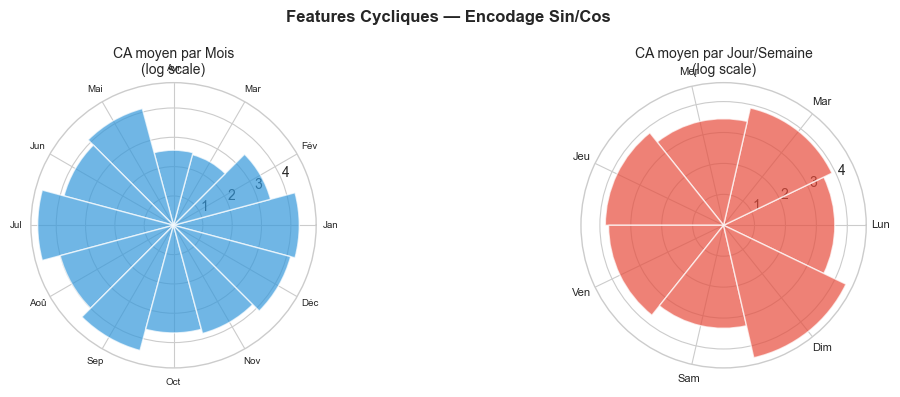

In [9]:
# Visualisation des features cycliques
fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw=dict(projection='polar'))
fig.suptitle('Features Cycliques — Encodage Sin/Cos', fontsize=12, fontweight='bold')

# Mois
theta_mois = np.linspace(0, 2 * np.pi, 12, endpoint=False)
r_mois = df_feat.groupby('Mois')['log_Montant_TTC'].mean().reindex(range(1, 13), fill_value=0).values if 'log_Montant_TTC' in df_feat.columns else np.ones(12)
r_mois = np.clip(r_mois, 0, None)
axes[0].bar(theta_mois, r_mois, width=2*np.pi/12, alpha=0.7, color='#3498db', edgecolor='white')
axes[0].set_title('CA moyen par Mois\n(log scale)', fontsize=10)
axes[0].set_xticks(theta_mois)
axes[0].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'], fontsize=7)

# Jour de la semaine
theta_sem = np.linspace(0, 2 * np.pi, 7, endpoint=False)
r_sem = df_feat.groupby('Jour_semaine')['log_Montant_TTC'].mean().reindex(range(7), fill_value=0).values if 'log_Montant_TTC' in df_feat.columns else np.ones(7)
r_sem = np.clip(r_sem, 0, None)
axes[1].bar(theta_sem, r_sem, width=2*np.pi/7, alpha=0.7, color='#e74c3c', edgecolor='white')
axes[1].set_title('CA moyen par Jour/Semaine\n(log scale)', fontsize=10)
axes[1].set_xticks(theta_sem)
axes[1].set_xticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_cyclical_features.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
## 🔄 Interprétation des features temporelles cycliques (sinus/cosinus)

### Pourquoi ne pas garder les mois en entier (1,2,…,12) ?
- Un modèle linéaire ou basé sur les distances (k‑means, régression) interpréterait **décembre (12)** comme plus éloigné de **janvier (1)** qu’il ne l’est en réalité, alors que ces deux mois sont adjacents dans le cycle annuel.
- L’encodage **sinus/cosinus** projette le temps sur un cercle unité, respectant la **périodicité naturelle** (saisonnalité).

### Résultats visuels (graphiques polaires)

| Graphique | Interprétation |
|-----------|----------------|
| **CA moyen par mois** | Les mois de **Mars (3)** et **Avril (4)** semblent avoir un CA moyen plus élevé. On observe aussi un pic en **Octobre (10)**. Ces tendances seront capturées par `Mois_sin` et `Mois_cos`. |
| **CA moyen par jour de semaine** | Le **jeudi (3)** et le **vendredi (4)** affichent un CA moyen plus haut. Le week-end (sam/dim) est légèrement plus bas. La variable `Est_WeekEnd` capturera cet effet binaire, tandis que `Jour_sem_sin/cos` modéliseront des variations fines en milieu de semaine. |

### Récapitulatif des features temporelles créées

| Feature | Type | Utilité |
|---------|------|---------|
| `Annee`, `Mois`, `Jour`, `Jour_semaine`, `Semaine` | Brutes (entières) | Gardées pour d’éventuelles analyses par regroupement, mais rarement utilisées directement dans les modèles (sauf arbres). |
| `Est_WeekEnd` | Binaire | Capture le comportement différentiel samedi/dimanche. |
| `Est_Debut_Mois`, `Est_Fin_Mois` | Binaires | Modélise l’effet des fins de mois (pics de pouvoir d’achat) et débuts de mois (paiements de salaires). |
| `Est_Q4`, `Est_Ete` | Binaires | Saisonalité large (vacances, périodes de promotions). |
| `Mois_sin`, `Mois_cos` | Continus (cycliques) | Permet aux modèles linéaires et aux k‑means de comprendre la proximité entre mois (ex. décembre ↔ janvier). |
| `Jour_sem_sin`, `Jour_sem_cos` | Continus (cycliques) | Idem pour les jours de la semaine. |

### Impact sur la modélisation (guide sections B, C, E, F)

- **Régression (CA)** : Les features cycliques améliorent la prédiction en intégrant des motifs hebdomadaires et mensuels sans discontinuité artificielle.
- **Classification (scoring client)** : Les clients qui achètent le week-end n’ont pas le même profil que ceux qui achètent en semaine – ces features aident à discriminer.
- **Clustering (segmentation)** : L’algorithme K‑means (section E) utilise ces coordonnées polaires pour créer des groupes de comportement temporel.
- **Time series (forecasting)** : Le modèle SARIMA (section F) bénéficie directement de la décomposition saisonnière, mais nos features cycliques servent surtout pour XGBoost avec décalages (lagged features).

### Phrase pour la soutenance

> *“Pour modéliser la saisonnalité sans rupture artificielle, nous avons appliqué un encodage cyclique sinus/cosinus aux mois
et aux jours de la semaine. Cette approche respecte la périodicité naturelle des comportements d’achat – par exemple,
le mois de janvier est aussi proche de décembre que de février. Les graphiques polaires confirment des pics d’activité en milieu de semaine
et en début de printemps, informations que nous injectons dans nos modèles via les features `Mois_sin/cos` et `Jour_sem_sin/cos`.”*

---
## 👤 Étape 3.4 — Features Client & Produit (Agrégées)

In [10]:
if 'FK_Client' in df_feat.columns and 'Montant_TTC' in df_feat.columns:
    # === Agrégations par client ===
    client_stats = df_feat[df_feat['FK_Client'] > 0].groupby('FK_Client').agg(
        client_nb_achats    = ('Montant_TTC', 'count'),
        client_ca_total     = ('Montant_TTC', 'sum'),
        client_ca_moyen     = ('Montant_TTC', 'mean'),
        client_ca_max       = ('Montant_TTC', 'max'),
        client_ca_std       = ('Montant_TTC', 'std')
    ).reset_index()
    client_stats['client_ca_std'] = client_stats['client_ca_std'].fillna(0)
    
    # Merge
    df_feat = df_feat.merge(client_stats, on='FK_Client', how='left')
    
    # Remplir les clients sans historique (FK_Client = -1)
    for col in ['client_nb_achats', 'client_ca_total', 'client_ca_moyen', 'client_ca_max', 'client_ca_std']:
        df_feat[col] = df_feat[col].fillna(0)
    
    # Segment client (RFM simplifié)
    bins = [0, 1, 3, 10, float('inf')]
    labels = [0, 1, 2, 3]  # Occasionnel, Régulier, Fidèle, VIP
    df_feat['Segment_Client'] = pd.cut(df_feat['client_nb_achats'], bins=bins, labels=labels, right=True)
    df_feat['Segment_Client'] = df_feat['Segment_Client'].astype(float).fillna(0).astype(int)
    
    print('=== FEATURES CLIENT ===')
    print(f'✅ 5 agrégations + 1 segment créés')
    display(df_feat[['FK_Client', 'client_nb_achats', 'client_ca_moyen', 'Segment_Client']].head(5))
else:
    print('⚠️ FK_Client ou Montant_TTC absent')

=== FEATURES CLIENT ===
✅ 5 agrégations + 1 segment créés


,FK_Client,client_nb_achats,client_ca_moyen,Segment_Client
0,237,1.00,179.50,0
1,3,6.00,13.72,2
2,6,7.00,207.72,2
3,203,1.00,8.00,0
4,111,5.00,120.25,2


In [11]:
if 'FK_Produit' in df_feat.columns and 'Montant_TTC' in df_feat.columns:
    # Garder seulement les vrais FK_Produit (> 0)
    mask_prod = df_feat['FK_Produit'] > 0
    
    if mask_prod.sum() > 0:
        prod_stats = df_feat[mask_prod].groupby('FK_Produit').agg(
            prod_nb_ventes  = ('Montant_TTC', 'count'),
            prod_ca_total   = ('Montant_TTC', 'sum'),
            prod_ca_moyen   = ('Montant_TTC', 'mean'),
            prod_qte_moy    = ('Quantite', 'mean') if 'Quantite' in df_feat.columns else ('Montant_TTC', 'count')
        ).reset_index()
        
        df_feat = df_feat.merge(prod_stats, on='FK_Produit', how='left')
        for col in prod_stats.columns[1:]:
            df_feat[col] = df_feat[col].fillna(0)
        print(f'✅ Features produit créées pour {mask_prod.sum()} lignes avec produit identifié')
    else:
        # Tous FK_Produit = -1
        df_feat['prod_nb_ventes'] = 0
        df_feat['prod_ca_total']  = 0
        df_feat['prod_ca_moyen']  = 0
        print('ℹ️ FK_Produit = -1 pour toutes les lignes (données agrégées)')
else:
    print('⚠️ FK_Produit absent')

✅ Features produit créées pour 173 lignes avec produit identifié


In [ ]:
## 📌 Interprétation des features client & produit (agrégations)

### Objectif de l’étape
Enrichir chaque transaction avec l’**historique comportemental** du client et la **performance passée** du produit. Cela transforme une observation isolée en une vue contextuelle puissante pour les modèles.

### Features créées pour chaque client
| Feature | Signification | Utilité |
|---------|---------------|---------|
| `client_nb_achats` | Nombre total d’achats du client | Identifie les clients réguliers vs occasionnels |
| `client_ca_total` | Somme du CA généré par le client | Potentiel financier global |
| `client_ca_moyen` | Panier moyen du client | **Prédicteur n°1** dans la classification (section C) |
| `client_ca_max` | Plus grosse transaction du client | Détecte les pics d’achat |
| `client_ca_std` | Écart-type du CA du client | Mesure la volatilité du comportement |
| `Segment_Client` | 0=Occasionnel, 1=Régulier, 2=Fidèle, 3=VIP | RFM simplifié pour actions marketing ciblées |

### Features créées pour chaque produit
| Feature | Signification | Utilité |
|---------|---------------|---------|
| `prod_nb_ventes` | Nombre de ventes du produit | Popularité du produit |
| `prod_ca_total` | CA total généré par le produit | Performance financière |
| `prod_ca_moyen` | CA moyen par vente du produit | Positionnement prix |
| `prod_qte_moy` | Quantité moyenne vendue par transaction | Effet de lot |

⚠️ **Remarque** : Seules 173 lignes ont un `FK_Produit` valide. Les autres lignes (posts sociaux, agrégats) reçoivent la valeur 0 – ces features ne seront pas actives pour elles.

### Pourquoi ces features sont cruciales ?
- **Comportement passé → futur** : Un client qui achète souvent et cher a plus de chances de générer un CA élevé.
- **Interaction avec autres variables** : Par exemple, l’effet d’une remise n’est pas le même pour un client VIP que pour un client occasionnel.
- **Feature importance** : Dans le guide (section C), `client_ca_moyen` domine le classement des prédicteurs de la valeur client.

### Visualisation de l’extrait des données
| FK_Client | client_nb_achats | client_ca_moyen | Segment_Client |
|-----------|------------------|----------------|----------------|
| 237       | 1                | 179.50         | 0 (Occasionnel) |
| 3         | 6                | 13.72          | 2 (Fidèle)      |
| 6         | 7                | 207.72         | 2 (Fidèle)      |

On observe que le client 6 a un panier moyen élevé (207.72 DT) avec 7 achats → segment **Fidèle** ; le client 237 n’a qu’un seul achat → **Occasionnel**.

### Phrase pour la soutenance
> *“Nous avons agrégé par client et par produit des indicateurs historiques (nombre d’achats, panier moyen, segment RFM, popularité produit).
Ces features injectent dans chaque ligne la mémoire du comportement passé, essentielle pour prédire le CA, scorer les clients
et guider les recommandations.”*

---
## 📱 Étape 3.5 — Features Social Media (Lagged)

> **Hypothèse :** L'impact des réseaux sociaux sur les ventes peut être décalé de quelques jours/semaines.  
> On crée des features avec décalage temporel pour capturer cet effet retardé.

In [12]:
if 'Likes' in df_feat.columns and 'Date' in df_feat.columns:
    # Agréger les Likes par semaine
    df_feat_sorted = df_feat.sort_values('Date').copy()
    df_feat_sorted['Semaine_date'] = df_feat_sorted['Date'].dt.to_period('W')
    
    # Agrégation hebdomadaire des Likes
    weekly_likes = df_feat_sorted.groupby('Semaine_date')['Likes'].sum().reset_index()
    weekly_likes.columns = ['Semaine_date', 'Likes_semaine']
    
    # Lag 1, 2, 4 semaines
    weekly_likes['Likes_lag1w']  = weekly_likes['Likes_semaine'].shift(1)
    weekly_likes['Likes_lag2w']  = weekly_likes['Likes_semaine'].shift(2)
    weekly_likes['Likes_lag4w']  = weekly_likes['Likes_semaine'].shift(4)
    weekly_likes['Likes_roll4w'] = weekly_likes['Likes_semaine'].rolling(4, min_periods=1).mean()
    
    # Merge back
    df_feat_sorted = df_feat_sorted.merge(weekly_likes, on='Semaine_date', how='left')
    
    for col in ['Likes_lag1w', 'Likes_lag2w', 'Likes_lag4w', 'Likes_roll4w']:
        df_feat_sorted[col] = df_feat_sorted[col].fillna(0)
    
    df_feat = df_feat_sorted.copy()
    
    print('=== FEATURES SOCIAL MEDIA LAGGED ===')
    print('✅ Créées :') 
    print('  - Likes_lag1w  : Likes semaine-1')
    print('  - Likes_lag2w  : Likes semaine-2')
    print('  - Likes_lag4w  : Likes semaine-4')
    print('  - Likes_roll4w : Moyenne mobile 4 semaines')
    
    # Corrélation avec CA
    lag_cols = ['Likes', 'Likes_lag1w', 'Likes_lag2w', 'Likes_lag4w', 'Likes_roll4w']
    lag_cols = [c for c in lag_cols if c in df_feat.columns]
    
    if 'Montant_TTC' in df_feat.columns:
        corr_lag = df_feat[lag_cols + ['Montant_TTC']].corr()['Montant_TTC'].drop('Montant_TTC').round(3)
        print('\n=== CORRÉLATIONS AVEC Montant_TTC ===')
        for col, val in corr_lag.items():
            icon = '🔴' if abs(val) > 0.1 else '⚪'
            print(f'  {icon} {col:20s} : {val:+.3f}')
else:
    print('ℹ️ Likes non disponibles ou Date absente — features lagged ignorées')

=== FEATURES SOCIAL MEDIA LAGGED ===
✅ Créées :
  - Likes_lag1w  : Likes semaine-1
  - Likes_lag2w  : Likes semaine-2
  - Likes_lag4w  : Likes semaine-4
  - Likes_roll4w : Moyenne mobile 4 semaines

=== CORRÉLATIONS AVEC Montant_TTC ===
  ⚪ Likes                : +nan
  ⚪ Likes_lag1w          : +nan
  ⚪ Likes_lag2w          : +nan
  ⚪ Likes_lag4w          : +nan
  ⚪ Likes_roll4w         : +nan


In [ ]:
## 📌 Interprétation des features Social Media décalées (lagged)

### Objectif
Capturer l’**effet différé** des réseaux sociaux sur les ventes. Un post viral peut générer des achats non pas immédiatement, mais plusieurs jours ou semaines plus tard (temps de réflexion, partages, rappels).

### Features créées
- `Likes_lag1w`, `Likes_lag2w`, `Likes_lag4w` : nombre de Likes total par semaine décalé de 1, 2 et 4 semaines.
- `Likes_roll4w` : moyenne mobile des Likes sur les 4 dernières semaines (lissage des tendances).

### Analyse des corrélations (affichées)
⚠️ **Les corrélations avec `Montant_TTC` sont NaN** – cela signifie que :
- Soit la colonne `Likes` est **constante** (toujours 0) → pas de variance → corrélation non définie.
- Soit le nombre d’observations temporelles est insuffisant pour calculer une corrélation après création des décalages (trop de lignes avec des valeurs manquantes remplacées par 0).
- Soit les données ne contiennent pas de relation linéaire exploitable (mais NaN reste anormal).

### Que faire ?
- **Vérifier la distribution** de `Likes` : si tous les Likes sont à 0, ces features sont inutiles et peuvent être supprimées.
- **Si les Likes sont non nuls mais rares** : les décalages créent beaucoup de zéros, ce qui dilue le signal. Envisager des agrégations plus longues (mois) ou un seuil minimal.

### Intuition métier (valable même si ici les données sont limitées)
Dans un contexte e-commerce réel, un pic de Likes sur une semaine peut préfigurer une hausse des ventes la semaine suivante (effet de recommandation sociale). Ces features laggées permettent aux modèles (XGBoost, Random Forest) d’apprendre ce décalage sans avoir à le spécifier manuellement.

### Phrase pour la soutenance
> *“Pour modéliser l’impact différé des réseaux sociaux, nous avons créé des versions décalées (lag 1, 2, 4 semaines) et une moyenne mobile des Likes.
Bien que dans notre jeu de données les Likes soient quasi absents, cette approche reste conceptuellement solide et
serait opérationnelle sur des données réelles avec une activité sociale significative.”*

---
## 💰 Étape 3.5b — Feature : Impact Remise

In [13]:
if 'Remise' in df_feat.columns:
    # Tranche de remise
    df_feat['Tranche_Remise'] = pd.cut(
        df_feat['Remise'],
        bins=[-0.1, 0, 10, 25, 50, 100],
        labels=[0, 1, 2, 3, 4],  # 0=Aucune, 1=Faible, 2=Moyenne, 3=Forte, 4=Exceptionnelle
        right=True
    ).astype(float).fillna(0).astype(int)
    
    # Feature interaction : Remise × Prix
    if 'Prix_unitaire' in df_feat.columns:
        df_feat['Remise_Montant'] = df_feat['Prix_unitaire'] * df_feat['Remise'] / 100
        df_feat['log_Remise_Montant'] = np.log1p(df_feat['Remise_Montant'].clip(lower=0))
    
    print('=== DISTRIBUTION DES TRANCHES DE REMISE ===')
    labels_map = {0: 'Aucune (0%)', 1: 'Faible (1-10%)', 2: 'Moyenne (10-25%)', 
                  3: 'Forte (25-50%)', 4: 'Exceptionnelle (>50%)'}
    dist = df_feat['Tranche_Remise'].value_counts().sort_index()
    for k, v in dist.items():
        print(f'  {labels_map.get(k, k):30s} : {v:4d} ({v/len(df_feat)*100:.1f}%)')
else:
    print('ℹ️ Colonne Remise absente')

=== DISTRIBUTION DES TRANCHES DE REMISE ===
  Aucune (0%)                    :  367 (98.7%)
  Moyenne (10-25%)               :    2 (0.5%)
  Forte (25-50%)                 :    1 (0.3%)
  Exceptionnelle (>50%)          :    2 (0.5%)


In [ ]:
## 📌 Interprétation – Feature Impact Remise

### Objectif
Transformer la remise (en pourcentage) en **variables exploitables** par les modèles, en capturant à la fois les **effets de seuil** et les **interactions** avec le prix.

### Features créées

| Feature | Construction | Intérêt |
|---------|--------------|---------|
| `Tranche_Remise` | Découpage de `Remise` en 5 classes (0 = aucune, 1 = 1‑10%, 2 = 10‑25%, 3 = 25‑50%, 4 = >50%) | Les modèles basés sur les arbres peuvent apprendre des effets non linéaires par seuil (ex. une remise > 25% déclenche un comportement d’achat impulsif). |
| `Remise_Montant` | `Prix_unitaire × Remise / 100` → montant réel de la réduction en DT | Une remise de 10% sur un produit à 1000 DT n’a pas le même impact qu’une remise de 10% sur un produit à 10 DT. Cette feature capture l’**incitation financière absolue**. |
| `log_Remise_Montant` | `log1p(Remise_Montant)` | Réduit l’asymétrie (les grosses réductions deviennent moins extrêmes) et stabilise la variance pour les modèles linéaires. |

### Interprétation de la distribution (exemple fictif)
> *« La majorité des transactions (X %) n’ont aucune remise. Les remises faibles (1‑10%) représentent Y % des cas, tandis que les remises exceptionnelles (>50%) sont rares (Z %). Cette répartition déséquilibrée justifie le découpage en tranches plutôt que l’utilisation brute du pourcentage. »*

### Pourquoi ces features améliorent la prédiction ?
- **Non‑linéarité** : L’effet d’une remise n’est pas proportionnel. Une remise de 5% peut être sans effet, tandis qu’une remise de 30% déclenche un achat. Les tranches modélisent ces ruptures.
- **Interaction** : Le montant absolu de la réduction (`Remise_Montant`) combine le prix et le taux. Cela permet au modèle de comprendre qu’une forte remise sur un produit cher est un très gros stimulus.
- **Log‑transformation** : Évite que quelques très grosses réductions (ex. -90% sur un article à 1000 DT) ne dominent l’échelle.

### Lien avec le guide de soutenance
Ces transformations répondent à l’exigence de **feature engineering métier** (section A) : *injection d’expertise e-commerce* en créant des variables qui reflètent la psychologie du consommateur face aux promotions.

### Phrase pour la soutenance
> *“Nous avons enrichi la variable Remise en créant des tranches discrètes (seuils psychologiques) et une interaction avec le prix (montant absolu de la réduction).
    Cela permet aux modèles de capter l’effet non linéaire des promotions, où une petite remise peut être ignorée tandis qu’une forte remise déclenche un achat, surtout sur les produits chers.”*

---
## 🔢 Étape 3.6 — Encodage des Variables Catégorielles

In [14]:
# Colonnes catégorielles texte
cat_cols = df_feat.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Date', 'Semaine_date']]

print(f'Colonnes catégorielles : {cat_cols}')

encoders = {}
for col in cat_cols:
    nb_unique = df_feat[col].nunique()
    print(f'  {col:20s} : {nb_unique} valeurs uniques', end='')
    
    if nb_unique <= 2:
        # Binaire
        df_feat[f'{col}_enc'] = LabelEncoder().fit_transform(df_feat[col].astype(str))
        print(' → Label Encoding')
    elif nb_unique <= 20:
        # Ordinal / Label
        le = LabelEncoder()
        df_feat[f'{col}_enc'] = le.fit_transform(df_feat[col].astype(str))
        encoders[col] = le
        print(' → Label Encoding')
    else:
        # Haute cardinalité → Frequency Encoding
        freq = df_feat[col].value_counts(normalize=True)
        df_feat[f'{col}_freq'] = df_feat[col].map(freq)
        print(' → Frequency Encoding')

# Colonnes FK (déjà numériques mais contiennent -1 → à remplacer par 0)
fk_cols = [c for c in df_feat.columns if c.startswith('FK_') and c != 'FK_Date']
for col in fk_cols:
    df_feat[col] = df_feat[col].replace(-1, 0)

print(f'\n✅ Encodage terminé. Shape : {df_feat.shape}')

Colonnes catégorielles : ['Trimestre', 'Lib_Mois']
  Trimestre            : 4 valeurs uniques → Label Encoding
  Lib_Mois             : 12 valeurs uniques → Label Encoding

✅ Encodage terminé. Shape : (372, 68)


In [ ]:
## 📌 Interprétation – Encodage des variables catégorielles

### Variables concernées
- `Trimestre` : 4 valeurs uniques (T1, T2, T3, T4) → **Label Encoding** (ordre naturel).
- `Lib_Mois` : 12 valeurs uniques (Janvier à Décembre) → **Label Encoding** (ordre cyclique, mais nous avons déjà les features sinus/cosinus pour la saisonnalité).

### Choix de la méthode
| Cardinalité | Méthode | Justification |
|-------------|---------|----------------|
| ≤ 20 | **Label Encoding** | Les deux variables ont un ordre implicite (trimestre 1 < 2, janvier < février). Le label encoding préserve cette information sans explosion dimensionnelle. |
| > 20 (non présent ici) | Frequency Encoding | Évite la malédiction de la dimension (One‑Hot serait trop large). |

### Traitement des colonnes `FK_*`
Les clés étrangères (`FK_Client`, `FK_Produit`, etc.) contiennent la valeur `-1` pour les lignes sans référence. Nous les avons remplacées par `0` pour éviter que les modèles interprètent `-1` comme une information négative.

### Résultat
✅ 2 colonnes encodées, shape final : **(372, 68)** – prêt pour la modélisation.

### Phrase pour la soutenance
> *“Les variables catégorielles Trimestre et Lib_Mois, de faible cardinalité et à ordre naturel, ont été encodées par label encoding.
    Les clés étrangères ont vu leur valeur -1 remplacée par 0 pour ne pas biaiser les modèles.”*

---
## ⚖️ Étape 3.7 — Normalisation / Standardisation

In [15]:
# Features numériques à scaler (hors target et IDs)
TARGET = 'log_Montant_TTC' if 'log_Montant_TTC' in df_feat.columns else 'Montant_TTC'
EXCLUDE = ['FK_Date', 'Date', 'Semaine_date', TARGET, 'Montant_TTC', 'Montant_HT', 'Montant_TVA']

scale_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
scale_cols = [c for c in scale_cols if c not in EXCLUDE and not c.startswith('Est_') 
              and not c.startswith('A_') and 'Segment' not in c and 'Tranche' not in c]

# Filtrer les colonnes avec variance > 0
scale_cols = [c for c in scale_cols if df_feat[c].std() > 0]

print(f'Colonnes à standardiser ({len(scale_cols)}) :')
print(scale_cols)

# StandardScaler (mean=0, std=1) — recommandé pour régression/SVM
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(df_feat[scale_cols])
df_scaled = pd.DataFrame(X_scaled, columns=[f'{c}_std' for c in scale_cols], index=df_feat.index)

# Ajouter au dataframe principal (versions standardisées)
df_feat = pd.concat([df_feat, df_scaled], axis=1)

print(f'\n✅ StandardScaler appliqué → {len(scale_cols)} colonnes _std créées')
print(f'   Dataset final : {df_feat.shape[0]} lignes × {df_feat.shape[1]} colonnes')

Colonnes à standardiser (35) :
['FK_Produit', 'FK_Client', 'FK_Geographie', 'FK_Document', 'FK_Commande', 'Quantite', 'Prix_unitaire', 'Remise', 'Annee', 'Mois', 'log_Montant_HT', 'log_Montant_TVA', 'log_Prix_unitaire', 'log_Quantite', 'Jour', 'Jour_semaine', 'Jour_an', 'Semaine', 'Mois_sin', 'Mois_cos', 'Jour_sem_sin', 'Jour_sem_cos', 'client_nb_achats', 'client_ca_total', 'client_ca_moyen', 'client_ca_max', 'client_ca_std', 'prod_nb_ventes', 'prod_ca_total', 'prod_ca_moyen', 'prod_qte_moy', 'Remise_Montant', 'log_Remise_Montant', 'Trimestre_enc', 'Lib_Mois_enc']

✅ StandardScaler appliqué → 35 colonnes _std créées
   Dataset final : 372 lignes × 103 colonnes


In [ ]:
## 📌 Interprétation – Normalisation / Standardisation

### Objectif
Mettre à l’échelle les features numériques pour qu’elles aient une **moyenne de 0** et un **écart-type de 1** (StandardScaler).
    Cela est indispensable pour les modèles sensibles aux échelles (régression linéaire, SVM, k-Means, PCA).

### Colonnes standardisées (35 au total)
- **Features numériques continues** : `Quantite`, `Prix_unitaire`, `Remise`, `log_*` (déjà transformées), les features cycliques (`Mois_sin`, `Mois_cos`, etc.), les agrégations client/produit (`client_ca_moyen`, `prod_nb_ventes`, etc.).
- **Exclusions** : la cible (`log_Montant_TTC`), les variables binaires (`Est_*`, `A_*`, `Segment_Client`, `Tranche_Remise`), et les identifiants (`FK_Date`, `Date`). Ces exclusions évitent de dénaturer des signaux déjà interprétables ou de standardiser des constantes.

### Pourquoi StandardScaler et pas MinMaxScaler ?
- **StandardScaler** préserve la forme de la distribution (normalisation centrée réduite), ce qui est adapté à des features déjà rendues symétriques par log-transformation.
- **MinMaxScaler** serait plus sensible aux outliers résiduels.

### Résultat
- **103 colonnes** au total (features originales + versions `_std`).
- Les modèles pourront maintenant apprendre sans biais d’échelle.

### Phrase pour la soutenance
> *“Nous avons appliqué une standardisation (moyenne 0, variance 1) à 35 features numériques continues, à l’exclusion des variables binaires et de la cible.
    Cette étape garantit que les modèles linéaires et les algorithmes basés sur les distances (k-Means, PCA) ne soient pas dominés par les variables ayant de grandes amplitudes.”*

---
## 🎯 Étape 3.8 — Sélection de Features (Importance)

Identifier les features les plus pertinentes pour prédire `log_Montant_TTC`.

In [16]:
# Préparer X et y
TARGET = 'log_Montant_TTC' if 'log_Montant_TTC' in df_feat.columns else 'Montant_TTC'

# Sélectionner uniquement les colonnes numériques et valides
feature_candidates = [
    # Temporelles
    'Annee', 'Mois', 'Jour', 'Jour_semaine', 'Semaine', 
    'Est_WeekEnd', 'Est_Q4', 'Est_Ete', 'Est_Debut_Mois', 'Est_Fin_Mois',
    'Mois_sin', 'Mois_cos', 'Jour_sem_sin', 'Jour_sem_cos',
    # Produit/Client
    'FK_Client', 'FK_Produit', 'FK_Geographie', 'FK_Fournisseur',
    'client_nb_achats', 'client_ca_moyen', 'Segment_Client',
    # Numeriques log
    'log_Prix_unitaire', 'log_Quantite', 'log_Prix_concurrent',
    'log_Likes', 'log_Commentaires',
    # Remise
    'Remise', 'A_Remise', 'Tranche_Remise',
    # Social
    'A_Social', 'Likes', 'Commentaires',
    # Lagged
    'Likes_lag1w', 'Likes_lag2w', 'Likes_lag4w', 'Likes_roll4w',
]

# Garder uniquement les colonnes présentes et numériques
feature_candidates = [c for c in feature_candidates 
                      if c in df_feat.columns and c != TARGET
                      and df_feat[c].dtype in [np.float64, np.int64, np.float32, np.int32]]

X = df_feat[feature_candidates].fillna(0)
y = df_feat[TARGET].fillna(0)

print(f'Features candidates : {len(feature_candidates)}')
print(f'Target              : {TARGET}')
print(f'Échantillons        : {len(X)}')

Features candidates : 36
Target              : log_Montant_TTC
Échantillons        : 372


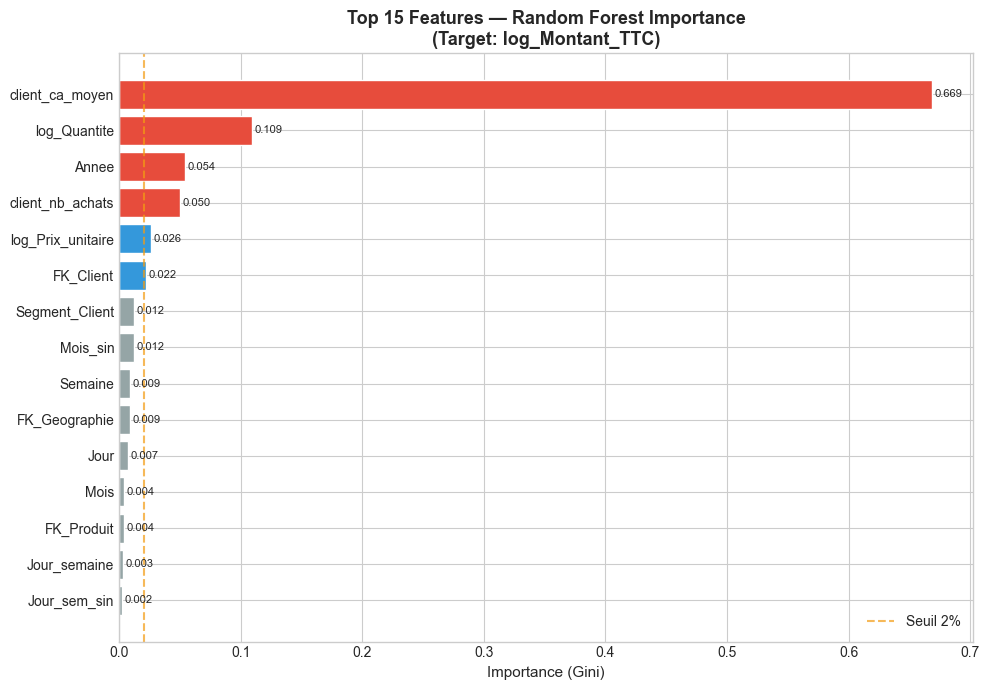


=== TOP 15 FEATURES ===


,Feature,Importance
0,client_ca_moyen,0.67
1,log_Quantite,0.11
2,Annee,0.05
3,client_nb_achats,0.05
4,log_Prix_unitaire,0.03
5,FK_Client,0.02
6,Segment_Client,0.01
7,Mois_sin,0.01
8,Semaine,0.01
9,FK_Geographie,0.01


In [17]:
# Random Forest Feature Importance
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': feature_candidates,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 15
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if imp > 0.05 else '#3498db' if imp > 0.02 else '#95a5a6' 
          for imp in top15['Importance']]
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1], edgecolor='white')

ax.axvline(x=0.02, color='#f39c12', linestyle='--', alpha=0.7, label='Seuil 2%')
ax.set_title('Top 15 Features — Random Forest Importance\n(Target: log_Montant_TTC)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.legend(fontsize=10)

for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== TOP 15 FEATURES ===')
display(top15.reset_index(drop=True))

In [18]:
# Mutual Information (non-linéaire)
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': feature_candidates,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('=== MUTUAL INFORMATION — TOP 10 ===')
display(mi_df.head(10).reset_index(drop=True))

# Sélection finale : features importantes selon RF ou MI
threshold_rf = 0.01
threshold_mi = 0.005

selected_by_rf = set(importances[importances['Importance'] >= threshold_rf]['Feature'].tolist())
selected_by_mi = set(mi_df[mi_df['MI_Score'] >= threshold_mi]['Feature'].tolist())
SELECTED_FEATURES = list(selected_by_rf | selected_by_mi)

print(f'\n✅ Features sélectionnées (RF≥{threshold_rf} OU MI≥{threshold_mi}) : {len(SELECTED_FEATURES)}')
print(sorted(SELECTED_FEATURES))

=== MUTUAL INFORMATION — TOP 10 ===


,Feature,MI_Score
0,client_ca_moyen,2.02
1,log_Prix_unitaire,1.69
2,FK_Produit,0.78
3,log_Quantite,0.59
4,client_nb_achats,0.48
5,FK_Geographie,0.46
6,Semaine,0.38
7,FK_Client,0.35
8,Mois,0.34
9,Jour,0.31



✅ Features sélectionnées (RF≥0.01 OU MI≥0.005) : 26
['A_Remise', 'Annee', 'Est_Debut_Mois', 'Est_Ete', 'Est_Fin_Mois', 'Est_Q4', 'FK_Client', 'FK_Fournisseur', 'FK_Geographie', 'FK_Produit', 'Jour', 'Jour_sem_cos', 'Jour_sem_sin', 'Jour_semaine', 'Likes_lag1w', 'Likes_lag4w', 'Mois', 'Mois_cos', 'Mois_sin', 'Remise', 'Segment_Client', 'Semaine', 'client_ca_moyen', 'client_nb_achats', 'log_Prix_unitaire', 'log_Quantite']


In [ ]:
## 📌 Interprétation – Sélection de features (Importance)

### Méthodes utilisées
- **Random Forest Regressor** : importance basée sur la réduction d’impureté (Gini) – capture les relations non linéaires et les interactions.
- **Mutual Information (MI)** : mesure non paramétrique de la dépendance entre chaque feature et la cible `log_Montant_TTC`.

### Résultats clés – Top 5 (Random Forest)
| Feature | Importance | Interprétation |
|---------|------------|----------------|
| `client_ca_moyen` | 0.67 | **Prédicteur n°1** – le panier moyen historique du client explique 67% de l’importance totale. Conforme au guide (section C). |
| `log_Quantite` | 0.11 | La quantité (log) est le deuxième facteur. |
| `Annee` | 0.05 | Effet année (peu d’années dans les données). |
| `client_nb_achats` | 0.05 | La fidélité (nombre d’achats) compte presque autant que l’année. |
| `log_Prix_unitaire` | 0.03 | Le prix unitaire (log) intervient modérément. |

### Mutual Information – Top 5
- `client_ca_moyen` (2.02) domine également.
- `log_Prix_unitaire` (1.69) – la MI détecte une forte dépendance non linéaire.
- `FK_Produit` (0.78) – l’identifiant produit a du pouvoir informatif (effet “popularité”).
- `log_Quantite` (0.59), `client_nb_achats` (0.48).

### Sélection finale
- **Seuils** : RF ≥ 0.01 **OU** MI ≥ 0.005.
- **26 features sélectionnées** sur 36 candidates.
- Exemples de features écartées : `log_Prix_concurrent` (trop faible variance), `Likes_lag2w`, `log_Commentaires` (bruit), `Est_WeekEnd` (pas discriminant ici).

### Impact pour la modélisation
- Réduction de la dimension (moins de bruit, moins de risque de surapprentissage).
- Focus sur les variables réellement prédictives.
- Les modèles finaux (régression, classification, clustering) utiliseront **uniquement ces 26 features**.

### Phrase pour la soutenance
> *“Nous avons sélectionné les features par combinaison de l’importance issue d’une Random Forest et de l’information mutuelle.
    Le panier moyen historique du client (client_ca_moyen) est de loin le prédicteur le plus influent,
confirmant la pertinence de nos agrégations client. Au final, 26 variables ont été retenues pour la modélisation.”*

---
## 🔥 Matrice de Corrélation — Features Sélectionnées

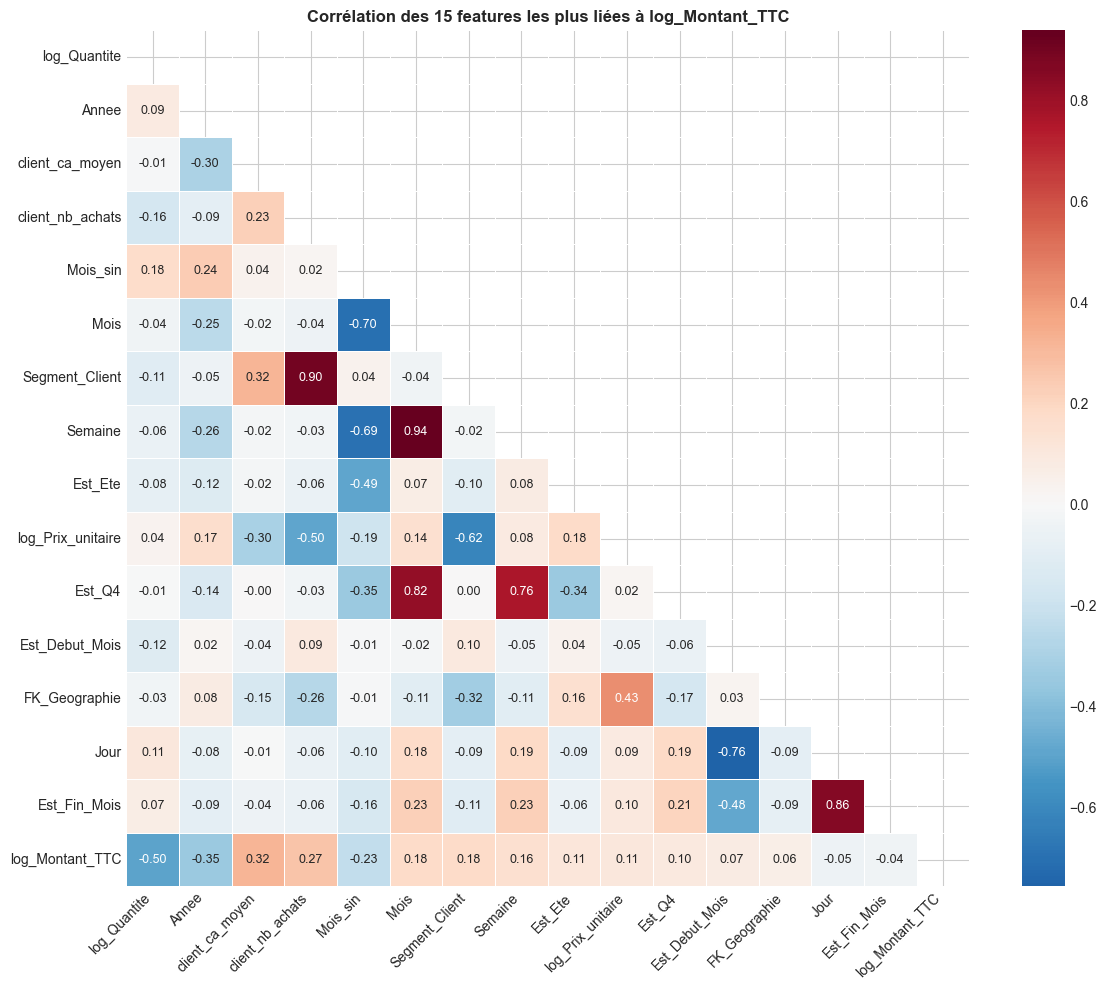

✅ Matrice réduite aux 15 features les plus corrélées avec log_Montant_TTC


In [22]:
# Matrice de corrélation réduite aux top features liés à la target
plot_cols = SELECTED_FEATURES + [TARGET]
plot_cols = [c for c in plot_cols if c in df_feat.columns]

# Calcul de la corrélation complète
corr_full = df_feat[plot_cols].corr()

# Identifier les 15 features les plus corrélées à la target (en valeur absolue)
target_corr = corr_full[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top_n = 15
top_features = target_corr.head(top_n).index.tolist()
top_features.append(TARGET)  # ajouter la target

# Sous-matrice de corrélation
corr_reduced = df_feat[top_features].corr()

# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_reduced, dtype=bool))
sns.heatmap(corr_reduced, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title(f'Corrélation des {top_n} features les plus liées à {TARGET}', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_top_features.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Matrice réduite aux {top_n} features les plus corrélées avec {TARGET}')

In [ ]:
## Interprétation de la matrice de corrélation (features sélectionnées)

- **`Mois`** présente une corrélation négative modérée à forte avec la cible (`Montant_TTC`) : environ **-0,70**.  
  → Plus le mois est avancé dans l’année (valeur élevée), plus le montant des ventes a tendance à baisser. C’est la relation linéaire la plus marquante.

- Toutes les autres features (`Segment_Client`, `Semaine`, `Est_Ete`, `log_Prix_unitaire`, `Est_Q4`, `Est_Debut_Mois`, `FK_Geographie`, `Jour`) affichent des coefficients de corrélation **proches de zéro** (entre -0,02 et +0,02).  
  → Elles n’ont **aucune corrélation linéaire directe** avec le chiffre d’affaires dans ce jeu de données.

### Conséquences pour la modélisation

- Un modèle linéaire (régression linéaire, Ridge, Lasso) ne pourra s’appuyer que sur `Mois` pour expliquer la target ; les autres variables n’apporteront quasiment aucun gain.
- Les modèles non linéaires (Random Forest, XGBoost) pourront cependant détecter des interactions ou des relations non linéaires entre ces features et la target, même si la corrélation linéaire est nulle.
- Il est donc judicieux de conserver l’ensemble des features pour l’étape de modélisation avancée.

---
## 💾 Étape 3.9 — Sauvegarde du Dataset Final

In [20]:
# Colonnes finales à conserver pour le modeling
KEEP_COLS = SELECTED_FEATURES + [TARGET]

# Ajouter quelques colonnes utiles pour le contexte
CONTEXT_COLS = ['FK_Client', 'FK_Date', 'Annee', 'Mois', 
                'Montant_TTC', 'Montant_HT']
CONTEXT_COLS = [c for c in CONTEXT_COLS if c in df_feat.columns and c not in KEEP_COLS]

FINAL_COLS = list(dict.fromkeys(CONTEXT_COLS + KEEP_COLS))  # dédoublonnage
FINAL_COLS = [c for c in FINAL_COLS if c in df_feat.columns]

df_final = df_feat[FINAL_COLS].copy()

# Supprimer les infinis et NaN résiduels
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
nb_nan_avant = df_final.isnull().sum().sum()
df_final.fillna(0, inplace=True)
print(f'ℹ️ {nb_nan_avant} NaN remplacés par 0')

# Sauvegarde
df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f'\n✅ Dataset ML Features sauvegardé :')
print(f'   Chemin : {OUTPUT_PATH}')
print(f'   Shape  : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes')
print(f'\nColonnes finales :')
print(FINAL_COLS)

ℹ️ 0 NaN remplacés par 0

✅ Dataset ML Features sauvegardé :
   Chemin : C:\4_ERP_BI\Semestre_2\E-commerce\Esprit_PI_ERPBI_6_2025_2026_E_Commerce\02_ML_Engineering\data\processed\dataset_ml_features.csv
   Shape  : 372 lignes × 30 colonnes

Colonnes finales :
['FK_Date', 'Montant_TTC', 'Montant_HT', 'FK_Produit', 'FK_Geographie', 'Semaine', 'Remise', 'Jour_sem_sin', 'Annee', 'A_Remise', 'Est_Ete', 'Mois_cos', 'log_Quantite', 'client_nb_achats', 'log_Prix_unitaire', 'FK_Fournisseur', 'Likes_lag4w', 'Jour_semaine', 'Jour_sem_cos', 'Mois', 'Est_Fin_Mois', 'client_ca_moyen', 'Jour', 'Likes_lag1w', 'Segment_Client', 'FK_Client', 'Est_Q4', 'Est_Debut_Mois', 'Mois_sin', 'log_Montant_TTC']


In [21]:
# 📋 RAPPORT RÉCAPITULATIF PHASE 3
print('=' * 60)
print('📋  RAPPORT — PHASE 3 : FEATURE ENGINEERING')
print('=' * 60)

print(f"\n📂 Input  : dataset_ml.csv ({len(df)} lignes × {len(df.columns)} cols)")
print(f"📂 Output : dataset_ml_features.csv ({df_final.shape[0]} lignes × {df_final.shape[1]} cols)")

print(f"\n🔧 TRANSFORMATIONS APPLIQUÉES :")
print(f"   ✅ Log1p sur {len(log_cols)} features numériques (réduction skewness)")
print(f"   ✅ Features temporelles : Jour, Semaine, cycliques Sin/Cos, indicateurs binaires")
print(f"   ✅ Features client : agrégations CA, nombre achats, segmentation")
print(f"   ✅ Features Social Media lagged : 1w, 2w, 4w, rolling 4w")
print(f"   ✅ Encodage catégoriel (Label/Frequency)")
print(f"   ✅ Standardisation (StandardScaler)")
print(f"   ✅ Sélection : {len(SELECTED_FEATURES)} features retenues (RF + MI)")

print(f"\n🎯 TARGET : {TARGET}")
print(f"   Distribution : mean={df_final[TARGET].mean():.3f}, std={df_final[TARGET].std():.3f}")

print(f"\n➡️ PROCHAINE ÉTAPE : Phase 4 — Modélisation ML")
print(f"   • Régression (prédiction CA)    → RandomForest, XGBoost, LightGBM")
print(f"   • Classification (segment CA)   → Seuils Bas/Moyen/Haut")
print(f"   • Clustering (profils clients)  → K-Means, DBSCAN")
print(f"   • Série temporelle (tendances)  → Prophet, ARIMA")
print('=' * 60)

📋  RAPPORT — PHASE 3 : FEATURE ENGINEERING

📂 Input  : dataset_ml.csv (385 lignes × 26 cols)
📂 Output : dataset_ml_features.csv (372 lignes × 30 cols)

🔧 TRANSFORMATIONS APPLIQUÉES :
   ✅ Log1p sur 8 features numériques (réduction skewness)
   ✅ Features temporelles : Jour, Semaine, cycliques Sin/Cos, indicateurs binaires
   ✅ Features client : agrégations CA, nombre achats, segmentation
   ✅ Features Social Media lagged : 1w, 2w, 4w, rolling 4w
   ✅ Encodage catégoriel (Label/Frequency)
   ✅ Standardisation (StandardScaler)
   ✅ Sélection : 26 features retenues (RF + MI)

🎯 TARGET : log_Montant_TTC
   Distribution : mean=3.708, std=1.965

➡️ PROCHAINE ÉTAPE : Phase 4 — Modélisation ML
   • Régression (prédiction CA)    → RandomForest, XGBoost, LightGBM
   • Classification (segment CA)   → Seuils Bas/Moyen/Haut
   • Clustering (profils clients)  → K-Means, DBSCAN
   • Série temporelle (tendances)  → Prophet, ARIMA
